In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
from sidm.tools.llpnanoaodschema import LLPNanoAODSchema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import awkward as ak

In [11]:
import inspect
import sidm.tools.sidm_processor as sp
import importlib

# 1. Force reload to ensure we read the latest file from disk
importlib.reload(sp)

# 2. Print the file path Python is actually loading from
print(f"Loading sidm_processor from: {sp.__file__}")

# 3. Inspect the source code of the running 'process' method
src = inspect.getsource(sp.SidmProcessor.process)

# 4. Check if the fix is present in the loaded code
if "processor.list_accumulator([flat_skim])" in src:
    print("\n✅ SUCCESS: The loaded code HAS the fix.")
else:
    print("\n❌ FAILURE: The loaded code STILL HAS THE BUG.")
    print("Search for 'skims[' in the source below:")
    # Print the relevant lines to debug
    for line in src.split('\n'):
        if "skims[" in line and "channel" in line:
            print(f"  > {line.strip()}")

Loading sidm_processor from: /home/cms-jovyan/SiDM/SIDM/sidm/tools/sidm_processor.py

✅ SUCCESS: The loaded code HAS the fix.


In [ ]:
client = scaleout.make_dask_client("tls://localhost:8786")
# client.restart()
client

In [2]:
do_Dask = False

if (do_Dask):
    import zipfile
    import os
    
    # Define the actual package path (sidm_path is the parent, so we append 'sidm')
    package_dir = os.path.join(sidm_path, "sidm")
    
    output_filename = "sidm_package.zip"
    
    print(f"Zipping source code from: {package_dir}")
    
    with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(package_dir):
            # 1. Exclude hidden folders like .git, .ipynb_checkpoints, __pycache__
            dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__']
            
            for file in files:
                # 2. Only zip source code and configs (skip .root, .parquet, .zip, etc.)
                if file.endswith(('.py', '.yaml', '.sh', '.txt', '.md')):
                    file_path = os.path.join(root, file)
                    # Keep the 'sidm/' prefix in the zip structure so imports work
                    # We calculate the relative path from the *parent* of sidm
                    arcname = os.path.relpath(file_path, start=sidm_path)
                    zf.write(file_path, arcname)
    
    print(f"Created {output_filename} (Size: {os.path.getsize(output_filename)/1024:.2f} KB)")
    
    client.upload_file("sidm_package.zip")
    print("Uploaded fresh code to workers.")

In [3]:
samples = ["2Mu2E_200GeV_5p0GeV_20p0mm"]
fileset = utilities.make_fileset(samples[0:1], 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = 3,
                                )
fileset

{'2Mu2E_200GeV_5p0GeV_20p0mm': {'files': ['root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3_part-0.root',
   'root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3_part-1.root',
   'root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3_part-10.root'],
  'metadata': {'skim_factor': 1.0, 'is_data': False, 'year': '2018'}}}

In [4]:
channels = ["base"]  # "baseNoLjNoLjsource", "baseNoLj", "base_ljObjCut", "base",
print(f"Running on sample: {samples[0]}")

Running on sample: 2Mu2E_200GeV_5p0GeV_20p0mm


In [16]:
from coffea.processor import AccumulatorABC
import sidm.tools.sidm_processor as sp

# 1. Define a robust List Accumulator that guarantees .add() exists
class SafeListAccumulator(list, AccumulatorABC):
    def identity(self):
        """Required by AccumulatorABC: returns a new empty accumulator"""
        return SafeListAccumulator([])

    def add(self, other):
        """Required by AccumulatorABC: handles addition"""
        if isinstance(other, list):
            self.extend(other)
        elif isinstance(other, SafeListAccumulator):
            self.extend(other)
        else:
            raise ValueError(f"Cannot add {type(other)} to SafeListAccumulator")

# 2. Monkey-patch the processor module to use OUR class instead of coffea's
# This forces the loaded sidm_processor module to use SafeListAccumulator
sp.processor.list_accumulator = SafeListAccumulator
print("✅ Monkey-patched sidm_processor to use SafeListAccumulator.")

# 3. Re-instantiate the processor to ensure it picks up the patch
p_skim = sp.SidmProcessor(
    channel_names=channels,
    hist_collection_names=["lj_base"],
    lj_reco_choices=["0.4"],
    skim_mode=True,
    verbose=True
)
print("Processor re-instantiated with SafeListAccumulator.")

✅ Monkey-patched sidm_processor to use SafeListAccumulator.
Processor re-instantiated with SafeListAccumulator.


In [5]:
p_skim = sidm_processor.SidmProcessor(
    channel_names=channels,
    hist_collection_names=["lj_base"],
    lj_reco_choices=["0.4"],
    skim_mode=True,
    verbose=True
)

if (not do_Dask):
    print("Starting Local Skim Run...")
    runner = processor.Runner(
        executor=processor.IterativeExecutor(),
        schema=llpnanoaodschema.LLPNanoAODSchema,
        skipbadfiles=True
    )
elif (do_Dask):
    print("Starting Dask Skim Run...")
    runner = processor.Runner(
        executor=processor.DaskExecutor(client=client, compression=None),
        schema=llpnanoaodschema.LLPNanoAODSchema,
        skipbadfiles=True
    )

# Run the processor
output = runner(fileset, treename="Events", processor_instance=p_skim)
dataset_key = list(output.keys())[0]
results = output[dataset_key]
results_original = results

print(output)

Output()

Starting Local Skim Run...


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Applying ljs mu_charge == 0

Applying cut: pass triggers

Applying cut: PV filter

Applying cut: >=2 LJs

Signal not in xs cfg, assuming 1fb
{'2Mu2E_200GeV_5p0GeV_20p0mm': {'cutflow': {'base': <sidm.tools.cutflow.Cutflow object at 0x7f806ea80fe0>}, 'hists': {'lj_n': <sidm.tools.histogram.Histogram object at 0x7f805df63d70>, 'lj_pt': <sidm.tools.histogram.Histogram object at 0x7f805df63e60>, 'lj_eta_phi': <sidm.tools.histogram.Histogram object at 0x7f8037ad02c0>, 'lj0_pt': <sidm.tools.histogram.Histogram object at 0x7f805eba2db0>, 'lj1_pt': <sidm.tools.histogram.Histogram object at 0x7f805e1a6300>, 'lj0_e': <sidm.tools.histogram.Histogram object at 0x7f80367dd880>, 'lj1_e': <sidm.tools.histogram.Histogram object at 0x7f80366115e0>, 'lj0_dRSpread': <sidm.tools.histogram.Histogram object at 0x7f80366118b0>, 'lj1_dRSpread': <sidm.tools.histogram.Histogram object at 0x7f8036611250>, 'lj_electronN': <sidm.tools.histogram.Histogram object at 0x7f8036613620>, 'lj_photonN': <sidm.tools.histogram.Histogram object at 0x7f8036613e30>, 'lj_electronPhotonN': <sidm.tools.histogram.Histogram object at 0x7

In [6]:
print(results_original.keys())
print(results_original['cutflow']['base'].print_table())
print()

print(results_original.keys())
print(results_original['cutflow']['base'].print_table(unweighted=True))
print()


for key in results_original["counters"]['0.4']['base'].keys():
    print(key, results_original["counters"]['0.4']['base'][key].value)
print()

print(results_original['hists'].keys())
import mplhep as hep
hist_list = []
hist_obj = results_original['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels[0], :] 
hist_list.append(hist_1d)

# plt.subplots(1,1,figsize=(6,6))
# plt.subplot(1,1,1)
# hep.histplot(hist_list) 
# plt.legend(["base (Yes CC) Pre"])
# plt.show()

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 59.8         59.8
pass triggers                16.5         16.5
PV filter                    59.8         16.5
>=2 LJs                      33.9         11.1
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection               6508.0       6508.0
pass triggers              1353.0       1353.0
PV filter                  4899.0       1353.0
>=2 LJs                    2773.0        907.0
None

Total LJs 1816
Gen As to muons 907
Gen As to electrons 907
Matched gen As to muons 905
Matched gen As to electrons 907

dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN'

In [7]:
results_original["metadata"]

{'n_evts': value_accumulator(int, 4899),
 'scaled_sum_weights': value_accumulator(float, np.float32(4899.0))}

In [8]:
skim_chunks = results_original["skims"]["0.4"][channels[0]]
print(skim_chunks)
print(f"\nSkim finished. Collected {len(skim_chunks)} chunks.")

if len(skim_chunks) > 0:
    skim_data = ak.concatenate(skim_chunks)
    print(f"Total events: {len(skim_data)}")

    cutflow_obj = results_original['cutflow']['base']
    original_sum_weights = cutflow_obj.cut_breakdown()[0]
    skimmed_sum_weights = cutflow_obj.cut_breakdown()[-1]

    my_skim_factor = skimmed_sum_weights / original_sum_weights
    print(my_skim_factor)

    print(f"Original Sum: {original_sum_weights}")
    print(f"Skimmed Sum:  {skimmed_sum_weights}")
    print(f"Skim Factor:  {my_skim_factor}")

    filename = "compatible_skim_test.parquet"
    print(f"Saving to {filename}...")
    
    ak.to_parquet(skim_data, filename)
    print("Success! File saved.")
    
else:
    print("Warning: No events selected!")

[<Array [{SoftActivityJetNjets2: 8, ...}, ...] type='316 * {SoftActivityJetN...'>, <Array [{SoftActivityJetNjets2: 19, ...}, ...] type='312 * {SoftActivityJet...'>, <Array [{SoftActivityJetNjets2: 1, ...}, ...] type='279 * {SoftActivityJetN...'>]

Skim finished. Collected 3 chunks.
Total events: 907
0.18513982
Original Sum: 59.83000183105469
Skimmed Sum:  11.076915740966797
Skim Factor:  0.18513981997966766
Saving to compatible_skim_test.parquet...
Success! File saved.


In [9]:
print("Reloading from Parquet...")
reloaded_events = NanoEventsFactory.from_parquet(
    filename, 
    schemaclass=llpnanoaodschema.LLPNanoAODSchema,
    metadata={"dataset": samples[0],
              "skim_factor": my_skim_factor,
             }
).events()

print("\n--- Integrity Check ---")
print(f"GenParticles: {len(reloaded_events.GenPart)}")
print(f"Has Flags?    {reloaded_events.GenPart.hasFlags('isPrompt')[:3]}")
print(f"Children?     {reloaded_events.GenPart.children[:3]}")

try:
    # Check if the cross-reference works now
    if "dsaMuons" in reloaded_events.fields:
        coll = reloaded_events.dsaMuons
    else:
        coll = reloaded_events.DSAMuon
        
    print(f"DSAMuon collection found: {coll}")
    # print(coll.fields)
    
    # Try accessing the cross-reference
    if hasattr(coll, "matched_muons"):
        print(f"✅ matched_muons exists! Example: {coll.matched_muons[0]}")
    else:
        print("❌ matched_muons still missing from the object.")
        
except Exception as e:
    print(f"⚠️ Error checking DSAMuons: {e}")
    
try:
    if "BS" in reloaded_events.fields:
        coll = reloaded_events.BS
        
    print(f"Beam Spot collection 'BS' found: {coll}")
    if hasattr(coll, "x"):
        print(f"✅ x exists! Example: {coll.x[0]}")
    else:
        print("❌ x still missing from the object.")
except Exception as e:
    print(f"⚠️ Error checking Beam Spot: {e}")

Reloading from Parquet...

--- Integrity Check ---
GenParticles: 907
Has Flags?    [[True, True, True, True, True, ..., False, False, False, False, False], ...]
Children?     [[[{eta: ??, mass: ??, phi: ??, pt: ??, genPartIdxMother: ??, ...}], ...], ...]
DSAMuon collection found: [??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
✅ matched_muons exists! Example: [[LLPMuon, ...], ...]
Beam Spot collection 'BS' found: [??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
✅ x exists! Example: [??]


In [10]:
# Full Analysis (Scalable Way)
from sidm.tools import utilities

# Define Inputs (Mimics standard fileset)
skim_fileset = {
    samples[0]: { 
        "files": ["compatible_skim_test.parquet"] 
        # In the future, this list will have ["part0.parquet", "part1.parquet", ...]
    }
}
channels_new = ['baseNoLj']

# Define Metadata (The skim factor we calculated)
skim_meta = {
             "dataset": samples[0],
             "skim_factor": my_skim_factor
            }

# Instantiate Processor
p_analysis = sidm_processor.SidmProcessor(
    channel_names=channels_new,
    hist_collection_names=["lj_base"],
    skim_mode=False
)

print("\n--- Running Parquet Analysis (via Utility) ---")

# Run
# Pass 'executor=client' here to run on Dask workers?
output = utilities.run_parquet_analysis(
    skim_fileset, 
    p_analysis, 
    metadata=skim_meta,
    # executor=client
)

# Validation
dataset_key = samples[0]
results = output[dataset_key]


--- Running Parquet Analysis (via Utility) ---
Submitting 1 tasks to Local...
Accumulating results...
Post-processing...
Signal not in xs cfg, assuming 1fb


dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 11.1         11.1
pass triggers                11.1         11.1
PV filter                    11.1         11.1
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                907.0        907.0
pass triggers               907.0        907.0
PV filter                   907.0        907.0
None

Histograms generated: 15
dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN', 'lj_dsaMuN', 'lj_pfMuN'])


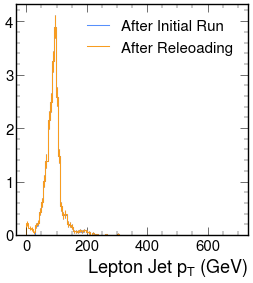

In [11]:
print(results.keys())
print(results['cutflow'][channels_new[0]].print_table())
print()

print(results.keys())
print(results['cutflow'][channels_new[0]].print_table(unweighted=True))
print()

print(f"Histograms generated: {len(results['hists'])}")
print(results['hists'].keys())

import mplhep as hep
hist_obj = results['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels_new[0], :] 
hist_list.append(hist_1d)

plt.subplots(1,1,figsize=(6,6))
plt.subplot(1,1,1)
hep.histplot(hist_list) 
plt.legend(["After Initial Run", "After Releoading"])
plt.show()

In [12]:
# Compare Original vs Reloaded Counts
orig_count = results_original["cutflow"][channels[0]].cut_breakdown()[-1]
reload_count = results["cutflow"][channels_new[0]].cut_breakdown()[-1]

print(f"Original Yield: {orig_count}")
print(f"Reloaded Yield: {reload_count}")

if abs(orig_count - reload_count) < 1e-5:
    print("SUCCESS: Yields are identical!")
else:
    print("WARNING: Yields differ!")

Original Yield: 11.076915740966797
Reloaded Yield: 11.076915740966797
SUCCESS: Yields are identical!
